In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import joblib
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix

np.random.seed(42)

: 

In [2]:
# Hämta MNIST-datasetet
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

# Definiera X och y
X = mnist["data"]
y = mnist["target"].astype(np.uint8)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Spara data och mål som NumPy-filer
np.save("X_mnist.npy",X)
np.save("y_mnist.npy", y)

# Kontrollera om några bilder är tomma (alla pixelvärden = 0)
empty_indices = np.where(X.sum(axis=1) == 0)[0]

# Skriv ut information om de tomma bilderna
print(f"Antal tomma bilder: {len(empty_indices)}")
print(f"Index för tomma bilder: {empty_indices}")

X shape: (70000, 784)
y shape: (70000,)
Antal tomma bilder: 0
Index för tomma bilder: []


In [3]:
# Ladda sparade NumPy-filer
def load_mnist_data():
    X = np.load("X_mnist.npy")  # Pixeldata
    y = np.load("y_mnist.npy").astype(np.uint8)  # Etiketter som uint8
    print(f"Data laddad: X shape = {X.shape}, y shape = {y.shape}")
    return X, y  # Returnera data och mål

# Använd funktionen för att ladda data
X, y = load_mnist_data()

Data laddad: X shape = (70000, 784), y shape = (70000,)


In [4]:
# Fördela data i tränings- och testset så att testdatan är 35% av den totala datan
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.4285, random_state=42)

# Ange antalet träningsobservationer som ska vara 25 000
train_size = 25000

# Fördela tränings- och valideringsdatan så att valideringsdatan utgör resterande del
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, train_size=train_size, random_state=42)

# Kontrollera storleken på tränings- och valideringsdatan
print(f'Train data shape: {X_train.shape}, {y_train.shape}')
print(f'Validation data shape: {X_val.shape}, {y_val.shape}')
print(f'Test data shape: {X_test.shape}, {y_test.shape}')

Train data shape: (25000, 784), (25000,)
Validation data shape: (15005, 784), (15005,)
Test data shape: (29995, 784), (29995,)


In [6]:
log_reg = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', LogisticRegression(n_jobs=-1))
])

log_reg_baseline = log_reg.fit(X_train, y_train)
score = log_reg_baseline.score(X_val, y_val)
joblib.dump(log_reg,'log_reg_trained.pkl')
print('Modellen är tränad, och sparad.')
print("LogisticRegression:", score)       

Modellen är tränad, och sparad.
LogisticRegression: 0.8967677440853049


In [9]:
log_reg_pipeline = joblib.load('log_reg_trained.pkl') 
y_pred = log_reg.predict(X_test)
print("Classification Report för LogisticRegression")
print(classification_report(y_test, y_pred))

Classification Report för LogisticRegression
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2966
           1       0.94      0.97      0.95      3380
           2       0.87      0.86      0.87      3004
           3       0.87      0.86      0.87      3026
           4       0.89      0.91      0.90      2844
           5       0.84      0.84      0.84      2699
           6       0.91      0.93      0.92      2975
           7       0.91      0.91      0.91      3185
           8       0.86      0.83      0.85      2887
           9       0.88      0.88      0.88      3029

    accuracy                           0.89     29995
   macro avg       0.89      0.89      0.89     29995
weighted avg       0.89      0.89      0.89     29995



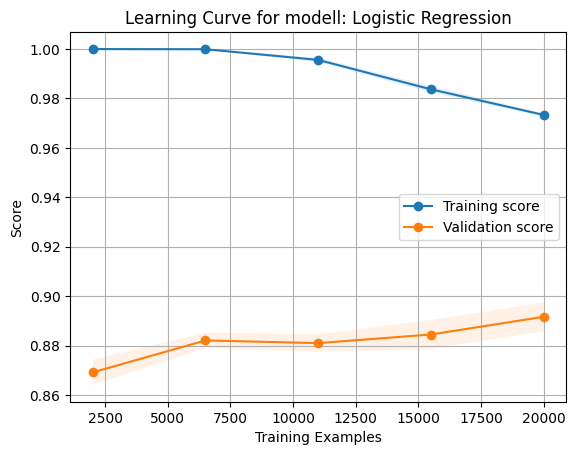

In [10]:
# Ladda den sparade pipelinen med modellen
log_reg = joblib.load('log_reg_trained.pkl')

# Funktion för att plotta inlärningskurva
def plot_learning_curve(estimator, title, X, y):
    train_sizes, train_scores, val_scores = learning_curve(estimator, X, y, cv=5, n_jobs=-1)
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', label='Training score')
    plt.plot(train_sizes, val_mean, 'o-', label='Validation score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
    plt.title(title)
    plt.xlabel('Training Examples')
    plt.ylabel('Score')
    plt.legend()
    plt.grid()
    plt.show()

# Plotta inlärningskurva för den laddade pipelinen med modellen
plot_learning_curve(log_reg, 'Learning Curve for modell: Logistic Regression', X_train, y_train)

In [11]:
# Ladda den tränade modellen
log_reg = joblib.load('log_reg_trained.pkl') 

# Gör prediktioner på valideringsdata med modellen
y_val_pred = log_reg.predict(X_val)

# Utvärdera modellens prestanda
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, average='macro')
recall = recall_score(y_val, y_val_pred, average='macro')
f1 = f1_score(y_val, y_val_pred, average='weighted')

# Samla resultaten
log_reg_results = [{
    'Model': 'LogisticRegression',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
}]

# Spara resultaten
joblib.dump(log_reg_results, 'log_reg_results.pkl')

# Konvertera listan till en DataFrame och visa resultaten
log_reg_results = pd.DataFrame(log_reg_results)
log_reg_results

,Model,Accuracy,Precision,Recall,F1-score
0,LogisticRegression,0.896768,0.895513,0.895471,0.896722


In [13]:
# Ladda den sparade modellen
log_reg = joblib.load('log_reg_trained.pkl')

# Definiera scorer
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# Beräkna cross-validation scores
cv_results = cross_validate(log_reg, X_train, y_train, cv=5, scoring=scoring)

# Skapa en lista med resultaten
log_reg_results = []
for fold in range(5):
    log_reg_results.append({
        'Fold': fold,
        'Accuracy': cv_results['test_accuracy'][fold],
        'Precision': cv_results['test_precision'][fold],
        'Recall': cv_results['test_recall'][fold],
        'F1-score': cv_results['test_f1'][fold]
    })

# Konvertera listan till en DataFrame
log_reg_results = pd.DataFrame(log_reg_results)

# Spara DataFrame med joblib
joblib.dump(log_reg_results, 'cross_validation_results.pkl')

# Visa DataFrame
log_reg_results

,Fold,Accuracy,Precision,Recall,F1-score
0,0,0.8888,0.887419,0.887441,0.887397
1,1,0.8864,0.885061,0.885143,0.884947
2,2,0.8872,0.886252,0.885925,0.885888
3,3,0.9020,0.900669,0.900471,0.900452
4,4,0.8938,0.892687,0.892462,0.892482


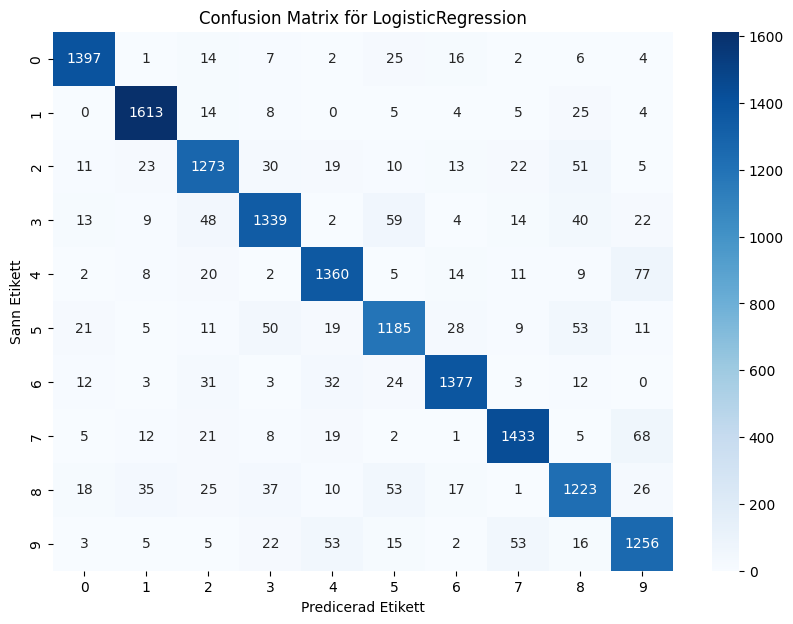

In [16]:
# Ladda tränade Logistiska regression modellen
log_reg = joblib.load('log_reg_trained.pkl')

# Gör prediktioner på testdata
y_val_pred = log_reg.predict(X_val)

# Skapa Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

# Visualisera Confusion Matrix som en heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix för LogisticRegression')
plt.xlabel('Predicerad Etikett')
plt.ylabel('Sann Etikett')
plt.show()

Visualisering, handskriven siffa, bild, dess faktiskt värde, och modellens prediction.

In [18]:
print("Misstag mellan 4 och 9:", cm[4, 9])
print("Misstag mellan 9 och 4:", cm[9, 4])
print('Största prediktionsfelet:', 77 /25000)

Misstag mellan 4 och 9: 77
Misstag mellan 9 och 4: 53
Största prediktionsfelet: 0.00308


Prediktioner med LogisticRegression


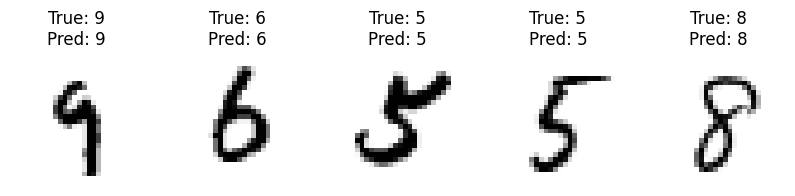

In [14]:
def plot_predictions(images, labels, predictions, n=5):
    plt.figure(figsize=(10, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='binary')
        plt.title(f'True: {labels[i]}\nPred: {predictions[i]}')
        plt.axis('off')
    plt.show()

# Visualiering, hur väl modellen predikterar 5 bilder från MNIST
examples = 5
X_example = X_train[:examples]
y_true_example = y_train[:examples]

#laddar in tränad modell till processen
trained_pipeline = joblib.load('log_reg_trained.pkl')
# Gör prediktioner med varje tränad modell
y_pred_example = trained_pipeline.predict(X_example)

print('Prediktioner med LogisticRegression')
plot_predictions(X_example, y_true_example, y_pred_example)